In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
sentiment_df=pd.read_csv("data/fear_greed_index.csv")
trader_df=pd.read_csv("data/historical_data.csv")


In [3]:
sentiment_df.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [6]:
trader_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [7]:
trader_df["date"]=pd.to_datetime(trader_df["Timestamp IST"],dayfirst=True).dt.date

In [8]:
sentiment_df["date"]=pd.to_datetime(sentiment_df["date"]).dt.date


In [9]:
merged_df=pd.merge(trader_df,sentiment_df,on="date",how="inner")
merged_df.head()
##merged_df.shape

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [10]:
daily_pnl=merged_df.groupby(["date","Account"])["Closed PnL"].sum().reset_index()
daily_pnl.head() 

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [11]:
sentiment_performance=merged_df.groupby("classification")["Closed PnL"].mean().reset_index()
sentiment_performance

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


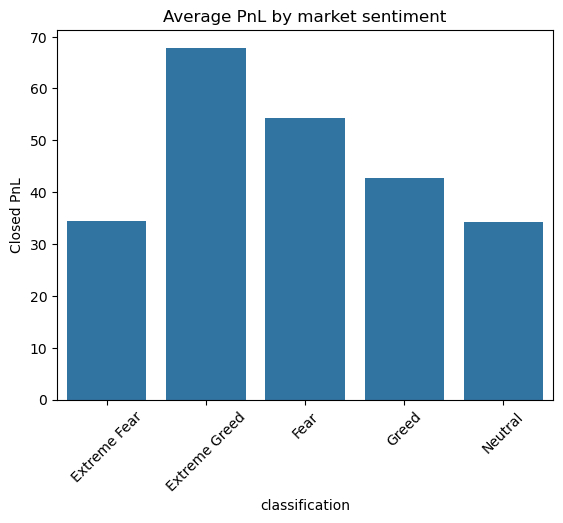

In [12]:
sns.barplot(x="classification",y="Closed PnL",data=sentiment_performance)
plt.xticks(rotation=45)
plt.title("Average PnL by market sentiment")
plt.show()

In [13]:
trade_count=merged_df.groupby(["date","classification"]).size().reset_index(name="num_trades")
trade_count.head()

,date,classification,num_trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


In [14]:
avg_trades=trade_count.groupby("classification")["num_trades"].mean().reset_index()
avg_trades

,classification,num_trades
0,Extreme Fear,1528.571429
1,Extreme Greed,350.807018
2,Fear,679.527473
3,Greed,260.637306
4,Neutral,562.477612


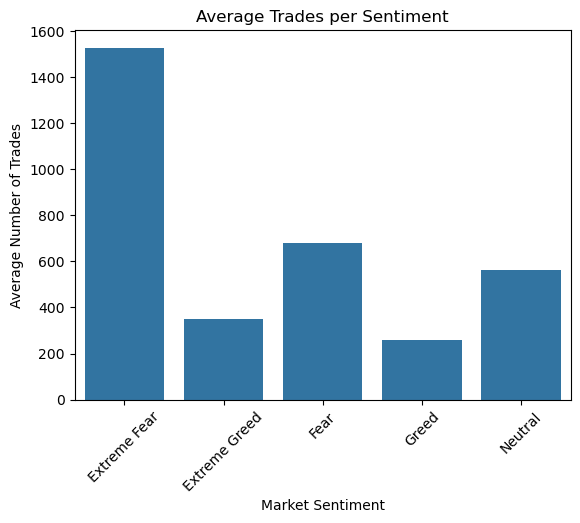

In [15]:
sns.barplot(x='classification', y='num_trades', data=avg_trades)
plt.xticks(rotation=45)
plt.title("Average Trades per Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Number of Trades")
plt.show()

In [16]:
risk_analysis=merged_df.groupby("classification")["Size USD"].mean().reset_index()
risk_analysis

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


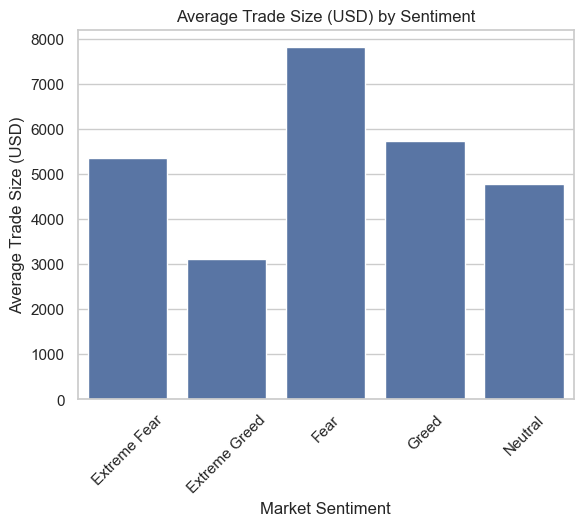

In [17]:
sns.set(style="whitegrid")
sns.barplot(x='classification', y='Size USD', data=risk_analysis)
plt.xticks(rotation=45)
plt.title("Average Trade Size (USD) by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

# Insights

1. Profit vs Sentiment  
From the analysis, it is clear that traders earn higher average profits during Extreme Greed periods. This likely happens because the market is trending upward, making it easier to follow momentum and capture gains.

2. Trading Activity  
I noticed that the number of trades increases significantly during Extreme Fear conditions. This suggests that traders become more reactive when the market is falling, possibly due to panic or attempts to recover losses quickly.

3. Risk Behavior  
Another key observation is that trade size (USD) is higher during Fear phases. This indicates that traders may be taking larger positions during uncertain conditions, which can increase risk exposure.

# Strategy Recommendations

1. Avoid overtrading during fear  
Since trading activity is highest during fear phases, it is important to avoid making too many impulsive trades. Traders should stay disciplined and avoid trying to recover losses quickly, as this can increase risk.

2. Take advantage of greedy markets carefully  
As profits are higher during greedy market conditions, traders can try to take advantage of the upward trend. However, it is still important to manage risk properly and avoid overexposure, as markets can reverse suddenly.

# Key Observation
There is a mismatch between behavior and profitability:
- Traders trade more and take larger risks during fear
- But profits are higher during greed

This indicates emotional bias affecting trading decisions.